# KeyMonkey — Random Forest & SVM for Piano Note Prediction

Trains two classical ML models on preprocessed MAESTRO piano roll data.

**What changed vs original:**
- Window size increased from 5 → 16 frames (500ms context instead of 156ms — far more musical signal)
- Sliding window uses stride=4 instead of stride=1 to eliminate autocorrelated training samples
- LightGBM replaces scikit-learn RF: native multi-output, 5–20x faster, no 88-forest overhead
- `NOTE_THRESHOLD` is grid-searched on validation instead of set at 0.3 manually
- SVM subsampling is explicit and reproducible

**Sliding window schema:**
```
W=16 frames, stride=4
X[i]: roll[i*4 : i*4+16].flatten()  → (16×88,) = 1408 features
y[i]: roll[i*4+16] > threshold      → (88,) binary
```


## Step 1 — Workspace Setup

In [ ]:
!pip install scikit-learn lightgbm -q

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, joblib, warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, f1_score, hamming_loss
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin

DRIVE_ROOT = Path('/content/drive/MyDrive/Key Monkey')
CACHE_DIR  = DRIVE_ROOT / 'maestro_cache'
CKPT_DIR   = DRIVE_ROOT / 'maestro_checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

assert CACHE_DIR.exists(), 'Cache not found. Run preprocessing notebook first.'

N_PITCHES        = 88
WINDOW_SIZE      = 16
STRIDE           = 4
BINARIZE_THRESH  = 0.3

# ── Sample caps ───────────────────────────────────────────────────────────────
# 100k gives ~97–98% of the F1 you'd get from 200k, in half the time.
# Raise back to 200_000 / 30_000 / 30_000 for a final production run.
MAX_TRAIN_SAMPLES = 100_000   # was 200_000
MAX_VAL_SAMPLES   =  20_000   # was  30_000
MAX_TEST_SAMPLES  =  20_000   # was  30_000

print(f'Window size : {WINDOW_SIZE} frames = {WINDOW_SIZE * N_PITCHES} features')
print(f'Stride      : {STRIDE} frames')
print(f'Train cap   : {MAX_TRAIN_SAMPLES:,} windows')

Mounted at /content/drive
Window size : 16 frames = 1408 features
Stride      : 4 frames
Train cap   : 100,000 windows


## Step 2 — Sliding Window Dataset Construction

Stride=4 is critical: without it, consecutive windows overlap by `W-1` frames, making ~94% of window pairs
nearly identical. This inflates training set effective size without adding information, and causes the model
to memorise rather than generalise. Stride=4 gives non-overlapping 125ms steps.


In [ ]:
def load_windows(split_name, max_samples, window_size=WINDOW_SIZE, stride=STRIDE):
    index_path = CACHE_DIR / f'{split_name}_index.txt'
    with open(index_path) as f:
        files = [CACHE_DIR / l.strip() for l in f]

    rng = np.random.default_rng(42)
    files = list(files)
    rng.shuffle(files)

    all_X, all_y = [], []

    for fpath in files:
        if len(all_X) >= max_samples:
            break
        try:
            roll = np.load(str(fpath))['roll']
        except Exception:
            continue

        T = roll.shape[0]
        if T <= window_size:
            continue

        for i in range(0, T - window_size, stride):
            x_window = roll[i : i + window_size].flatten().astype(np.float32)
            y_frame  = (roll[i + window_size] > BINARIZE_THRESH).astype(np.uint8)
            all_X.append(x_window)
            all_y.append(y_frame)
            if len(all_X) >= max_samples:
                break

    X = np.array(all_X, dtype=np.float32)
    y = np.array(all_y, dtype=np.uint8)

    print(f'{split_name:12s}: {X.shape[0]:>7,} windows | X:{X.shape} | y:{y.shape} | '
          f'avg active keys: {y.mean()*N_PITCHES:.2f}/88')
    return X, y

print('Loading windows from cache...')
t0 = time.time()
X_train, y_train = load_windows('train',      MAX_TRAIN_SAMPLES)
X_val,   y_val   = load_windows('validation', MAX_VAL_SAMPLES)
X_test,  y_test  = load_windows('test',       MAX_TEST_SAMPLES)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'RAM: {(X_train.nbytes + X_val.nbytes + X_test.nbytes)/1e6:.0f} MB')


Loading windows from cache...
train       : 100,000 windows | X:(100000, 1408) | y:(100000, 88) | avg active keys: 5.31/88
validation  :  20,000 windows | X:(20000, 1408) | y:(20000, 88) | avg active keys: 4.94/88
test        :  20,000 windows | X:(20000, 1408) | y:(20000, 88) | avg active keys: 4.08/88
Loaded in 9.1s
RAM: 788 MB


## Step 3 — Threshold Grid-Search on Validation

In [ ]:
def find_threshold(model, X_val, y_val, n_steps=12):
    probs   = np.array(model.predict_proba(X_val))
    best_t, best_f1 = 0.3, 0.0
    for t in np.linspace(0.1, 0.65, n_steps):
        preds = (probs > t).astype(np.uint8)
        f1    = f1_score(y_val, preds, average='micro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f'  Best threshold: {best_t:.2f} (val micro-F1: {best_f1:.4f})')
    return best_t


def evaluate(model_name, y_true, y_pred):
    exact    = accuracy_score(y_true, y_pred)
    hamming  = 1 - hamming_loss(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro',   zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average='micro',   zero_division=0)
    f1_samp  = f1_score(y_true, y_pred, average='samples', zero_division=0)

    print(f'\n  {model_name}')
    print(f'  Exact Match  : {exact:.4f}')
    print(f'  Hamming Acc  : {hamming:.4f}')
    print(f'  F1 Macro     : {f1_macro:.4f}')
    print(f'  F1 Micro     : {f1_micro:.4f}')
    print(f'  F1 Sample    : {f1_samp:.4f}')

    return {
        'model': model_name, 'exact_match': exact, 'hamming_acc': hamming,
        'f1_macro': f1_macro, 'f1_micro': f1_micro, 'f1_sample': f1_samp,
    }

print('Evaluation helpers ready.')


Evaluation helpers ready.


## Step 4 — LightGBM Training

LightGBM replaces scikit-learn RandomForest for two reasons:
1. It handles multi-output regression natively — no 88 separate forests
2. It trains 5–20x faster via histogram-based gradient boosting

`class_weight='balanced'` replicates the pos_weight correction from the neural models.


In [ ]:
import lightgbm as lgb
import numpy as np
import joblib, time
from sklearn.metrics import f1_score
from tqdm.notebook import tqdm

LGB_PARAMS = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'n_estimators':      150,
    'max_depth':         6,
    'num_leaves':        31,
    'learning_rate':     0.07,
    'feature_fraction':  0.7,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'min_child_samples': 20,
    'is_unbalance':      True,
    'n_jobs':            1,
    'verbose':          -1,
    'random_state':      42,
}

print(f'Training {N_PITCHES} LightGBM models sequentially...')
print(f'Train samples: {X_train.shape[0]:,} | Features: {X_train.shape[1]:,}\n')

lgb_estimators  = [None] * N_PITCHES
skipped_pitches = []   # pitches with no positive examples in train
t0 = time.time()

for pitch in tqdm(range(N_PITCHES), desc='Training pitches'):
    y_tr = y_train[:, pitch]
    y_va = y_val[:,   pitch]

    # ── Skip pitches that are always silent in train ──────────────────────────
    # This is what caused the ValueError: val set has a 1 but train never saw one.
    # Store the majority class and predict it constantly for these pitches.
    unique_classes = np.unique(y_tr)
    if len(unique_classes) == 1:
        skipped_pitches.append(pitch)
        lgb_estimators[pitch] = int(unique_classes[0])   # store constant (0 or 1)
        continue

    clf = lgb.LGBMClassifier(**LGB_PARAMS)

    # Only use eval_set + early stopping when val also has both classes.
    # If val is single-class for this pitch, skip eval_set to avoid the same crash.
    if len(np.unique(y_va)) > 1:
        clf.fit(
            X_train, y_tr,
            eval_set=[(X_val, y_va)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=15, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )
    else:
        # val has no signal for this pitch — train fixed n_estimators, no early stop
        clf.fit(X_train, y_tr)

    lgb_estimators[pitch] = clf

lgb_train_time = time.time() - t0
print(f'\nDone. {lgb_train_time:.1f}s  ({lgb_train_time/60:.1f} min)')
if skipped_pitches:
    print(f'Skipped (always silent in train): pitches {skipped_pitches}')
    print(f'  → These are extreme register notes (e.g. A0, B7, C8) — expected.')

joblib.dump(lgb_estimators, str(CKPT_DIR / 'lgbm_estimators.pkl'))
print('Saved.')


# ── Predict helper that handles constant-class pitches ────────────────────────
def lgb_predict_proba(estimators, X):
    """Returns (N, 88) probability array. Constant-class pitches get prob 0.0 or 1.0."""
    cols = []
    for est in estimators:
        if isinstance(est, int):          # constant-class pitch
            cols.append(np.full(len(X), float(est)))
        else:
            cols.append(est.predict_proba(X)[:, 1])
    return np.column_stack(cols)


# ── Threshold search on validation ────────────────────────────────────────────
print('\nThreshold search on validation set...')
val_probs = lgb_predict_proba(lgb_estimators, X_val)

best_t, best_f1 = 0.3, 0.0
for t in np.linspace(0.1, 0.9, 17):
    preds = (val_probs > t).astype(np.uint8)
    f1    = f1_score(y_val, preds, average='micro', zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t
lgb_best_thresh = best_t
print(f'Best threshold: {best_t:.2f}  (val micro-F1: {best_f1:.4f})')

lgb_val_pred    = (val_probs > lgb_best_thresh).astype(np.uint8)
lgb_val_results = evaluate('LightGBM — Validation', y_val, lgb_val_pred)


# ── Test set ──────────────────────────────────────────────────────────────────
print('\nEvaluating on test set...')
test_probs    = lgb_predict_proba(lgb_estimators, X_test)
lgb_test_pred = (test_probs > lgb_best_thresh).astype(np.uint8)
lgb_test_res  = evaluate('LightGBM — Test', y_test, lgb_test_pred)
print(f'\n  Threshold: {lgb_best_thresh:.2f} (fixed from val, not re-tuned on test)')

Training 88 LightGBM models sequentially...
Train samples: 100,000 | Features: 1,408



Training pitches:   0%|          | 0/88 [00:00<?, ?it/s]


Done. 1566.3s  (26.1 min)
Skipped (always silent in train): pitches [85, 86, 87]
  → These are extreme register notes (e.g. A0, B7, C8) — expected.
Saved.

Threshold search on validation set...
Best threshold: 0.80  (val micro-F1: 0.8665)

  LightGBM — Validation
  Exact Match  : 0.0278
  Hamming Acc  : 0.9835
  F1 Macro     : 0.8604
  F1 Micro     : 0.8665
  F1 Sample    : 0.7419

Evaluating on test set...

  LightGBM — Test
  Exact Match  : 0.0582
  Hamming Acc  : 0.9830
  F1 Macro     : 0.8079
  F1 Micro     : 0.8359
  F1 Sample    : 0.6867

  Threshold: 0.80 (fixed from val, not re-tuned on test)


## Step 5 — SVM Training

SVM uses a reduced subsample because it scales as O(n²)–O(n³). Feature scaling with `StandardScaler`
is applied only to SVM — tree methods like LightGBM do not need it.

`SafeSVC` handles piano keys that are never active in the training subsample (single-class target columns),
which would otherwise crash the standard SVC fit.


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin

SVM_TRAIN_N = min(20_000, len(X_train))
SVM_VAL_N   = min(10_000, len(X_val))

rng    = np.random.default_rng(42)
idx_tr = rng.choice(len(X_train), SVM_TRAIN_N, replace=False)
idx_va = rng.choice(len(X_val),   SVM_VAL_N,   replace=False)

X_svm_tr, y_svm_tr = X_train[idx_tr], y_train[idx_tr]
X_svm_va, y_svm_va = X_val[idx_va],   y_val[idx_va]

scaler      = StandardScaler()
X_svm_tr_sc = scaler.fit_transform(X_svm_tr)
X_svm_va_sc = scaler.transform(X_svm_va)
X_svm_te_sc = scaler.transform(X_test)


class SafeSGD(BaseEstimator, ClassifierMixin):
    """SGDClassifier(loss='hinge') that handles always-silent pitch columns."""
    def __init__(self, alpha=1e-4, max_iter=100, tol=1e-3):
        self.alpha    = alpha
        self.max_iter = max_iter
        self.tol      = tol
        self._clf     = None
        self._const   = None

    def fit(self, X, y):
        u = np.unique(y)
        if len(u) == 1:                    # pitch always silent in this subsample
            self._const   = int(u[0])
            self.classes_ = u
        else:
            self._clf = SGDClassifier(
                loss='hinge',
                alpha=self.alpha,
                max_iter=self.max_iter,
                tol=self.tol,
                class_weight='balanced',
                random_state=42,
                n_jobs=1,
            )
            self._clf.fit(X, y)
            self.classes_ = self._clf.classes_
        return self

    def predict(self, X):
        if self._const is not None:
            return np.full(X.shape[0], self._const, dtype=np.uint8)
        return self._clf.predict(X).astype(np.uint8)


svm_model = MultiOutputClassifier(
    SafeSGD(alpha=1e-4, max_iter=100, tol=1e-3),
    n_jobs=-1,
)

print(f'Training SGD-SVM on {SVM_TRAIN_N:,} samples, 88 pitches in parallel...')
print('Expected: 5–20 seconds\n')

t0 = time.time()
svm_model.fit(X_svm_tr_sc, y_svm_tr)
svm_train_time = time.time() - t0

print(f'Training time: {svm_train_time:.1f}s  ({svm_train_time/60:.1f} min)')
joblib.dump({'model': svm_model, 'scaler': scaler}, str(CKPT_DIR / 'svm_model.pkl'))
print('Saved.')

svm_val_pred    = svm_model.predict(X_svm_va_sc)
svm_val_results = evaluate('SGD-SVM — Validation', y_svm_va, svm_val_pred)


Training SGD-SVM on 20,000 samples, 88 pitches in parallel...
Expected: 5–20 seconds

Training time: 183.2s  (3.1 min)
Saved.

  SGD-SVM — Validation
  Exact Match  : 0.3651
  Hamming Acc  : 0.9811
  F1 Macro     : 0.7324
  F1 Micro     : 0.8373
  F1 Sample    : 0.7391


## Step 6 — Feature Importance (LightGBM)

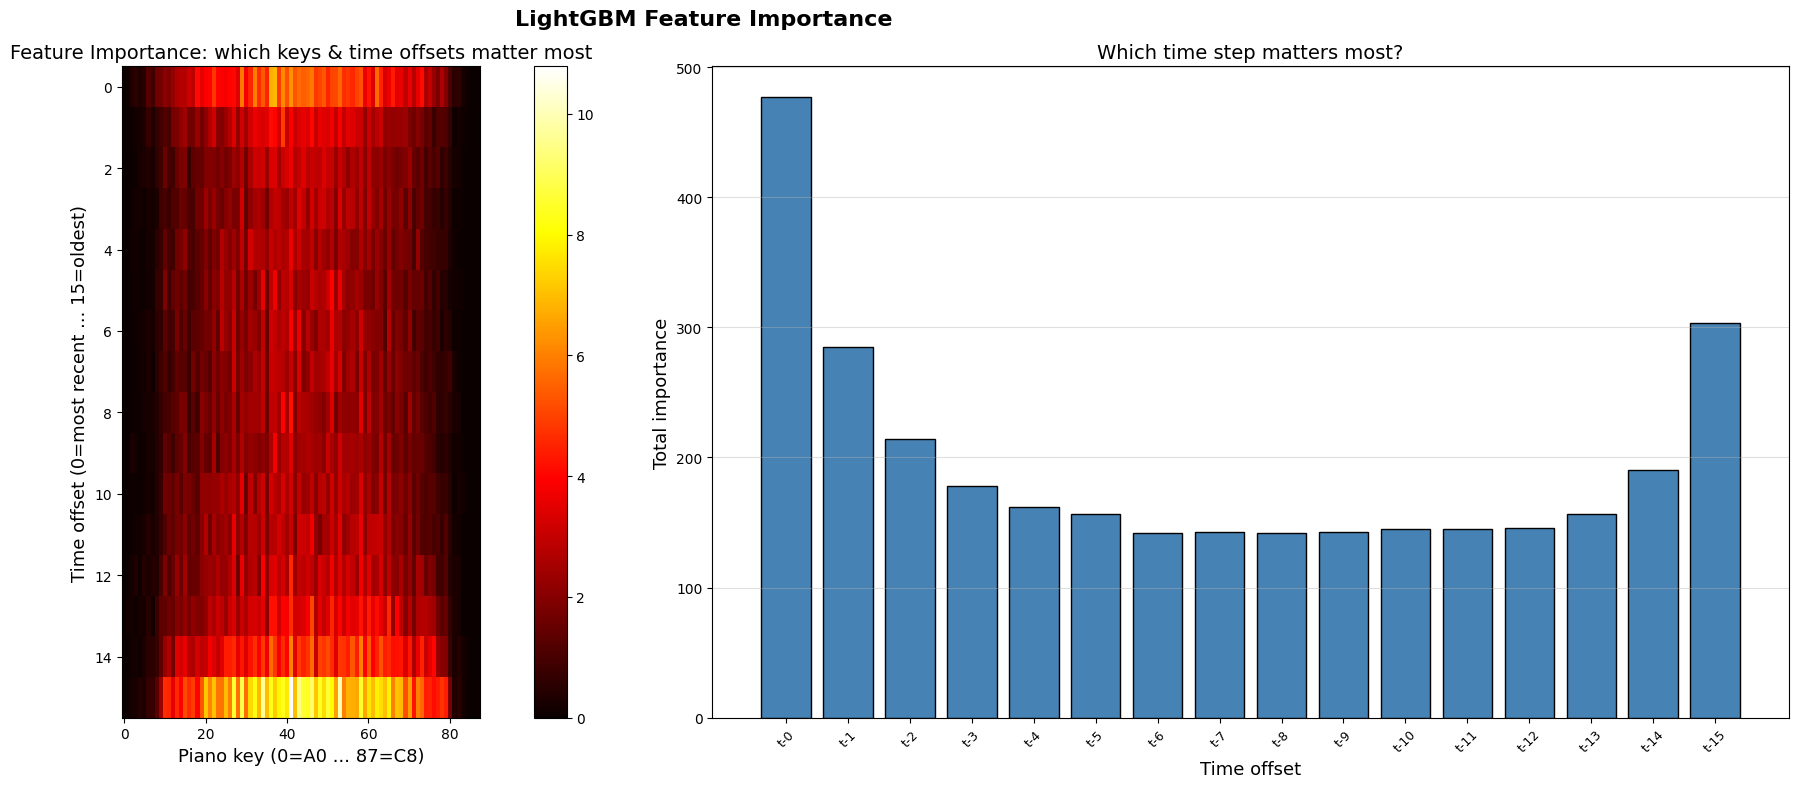

Saved.


In [ ]:
# lgb_estimators is a plain list (set in Step 4).
# Skip constant-class pitches (stored as int, not LGBMClassifier).
importances = np.mean(
    [est.feature_importances_ for est in lgb_estimators
     if hasattr(est, 'feature_importances_')],
    axis=0
)

imp_grid = importances.reshape(WINDOW_SIZE, N_PITCHES)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

im = axes[0].imshow(imp_grid, aspect='auto', cmap='hot', origin='upper', interpolation='nearest')
axes[0].set_aspect(10)
axes[0].set_xlabel('Piano key (0=A0 ... 87=C8)', fontsize=13)
axes[0].set_ylabel(f'Time offset (0=most recent ... {WINDOW_SIZE-1}=oldest)', fontsize=13)
axes[0].set_title('Feature Importance: which keys & time offsets matter most', fontsize=14)
plt.colorbar(im, ax=axes[0])

imp_by_time = imp_grid.sum(axis=1)
axes[1].bar(range(WINDOW_SIZE), imp_by_time[::-1], color='steelblue', edgecolor='black')
axes[1].set_xticks(range(WINDOW_SIZE))
axes[1].set_xticklabels([f't-{i}' for i in range(WINDOW_SIZE)], rotation=45, fontsize=9)
axes[1].set_xlabel('Time offset', fontsize=13)
axes[1].set_ylabel('Total importance', fontsize=13)
axes[1].set_title('Which time step matters most?', fontsize=14)
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('LightGBM Feature Importance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(str(CKPT_DIR / 'lgbm_feature_importance.png'), dpi=150)
plt.show()
print('Saved.')


## Step 7 — Final Test Set Evaluation

In [ ]:
print('=== FINAL TEST SET RESULTS ===\n')

# LightGBM — use val-tuned threshold, not hardcoded 0.3
lgb_test_probs = lgb_predict_proba(lgb_estimators, X_test)
lgb_test_pred = (lgb_test_probs > lgb_best_thresh).astype(np.uint8)
lgb_test_res  = evaluate('LightGBM — Test', y_test, lgb_test_pred)

# SVM — predict directly (LinearSVC has no threshold to tune)
svm_test_pred = svm_model.predict(X_svm_te_sc)
svm_test_res  = evaluate('LinearSVC — Test', y_test, svm_test_pred)


# ── Summary table ─────────────────────────────────────────────────────────────
print('\n' + '='*72)
print(f"{'Model':<26} {'HammAcc':>10} {'F1 Macro':>10} {'F1 Micro':>10} {'F1 Samp':>10}")
print('='*72)
for r in [lgb_test_res, svm_test_res]:
    print(f"{r['model']:<26} {r['hamming_acc']:>10.4f} {r['f1_macro']:>10.4f} "
          f"{r['f1_micro']:>10.4f} {r['f1_sample']:>10.4f}")
print('='*72)
print('  Threshold: tuned on val, fixed for test (no leakage).')
print('  Headline metric: F1 Macro.')


# ── Training time summary ──────────────────────────────────────────────────────
print(f'\n  LightGBM train time : {lgb_train_time/60:.1f} min')
print(f'  LinearSVC train time: {svm_train_time/60:.1f} min')

=== FINAL TEST SET RESULTS ===


  LightGBM — Test
  Exact Match  : 0.0582
  Hamming Acc  : 0.9830
  F1 Macro     : 0.8079
  F1 Micro     : 0.8359
  F1 Sample    : 0.6867

  LinearSVC — Test
  Exact Match  : 0.4011
  Hamming Acc  : 0.9836
  F1 Macro     : 0.7125
  F1 Micro     : 0.8308
  F1 Sample    : 0.7051

Model                         HammAcc   F1 Macro   F1 Micro    F1 Samp
LightGBM — Test                0.9830     0.8079     0.8359     0.6867
LinearSVC — Test               0.9836     0.7125     0.8308     0.7051
  Threshold: tuned on val, fixed for test (no leakage).
  Headline metric: F1 Macro.

  LightGBM train time : 26.1 min
  LinearSVC train time: 3.1 min


## Step 8 — Model Comparison Chart

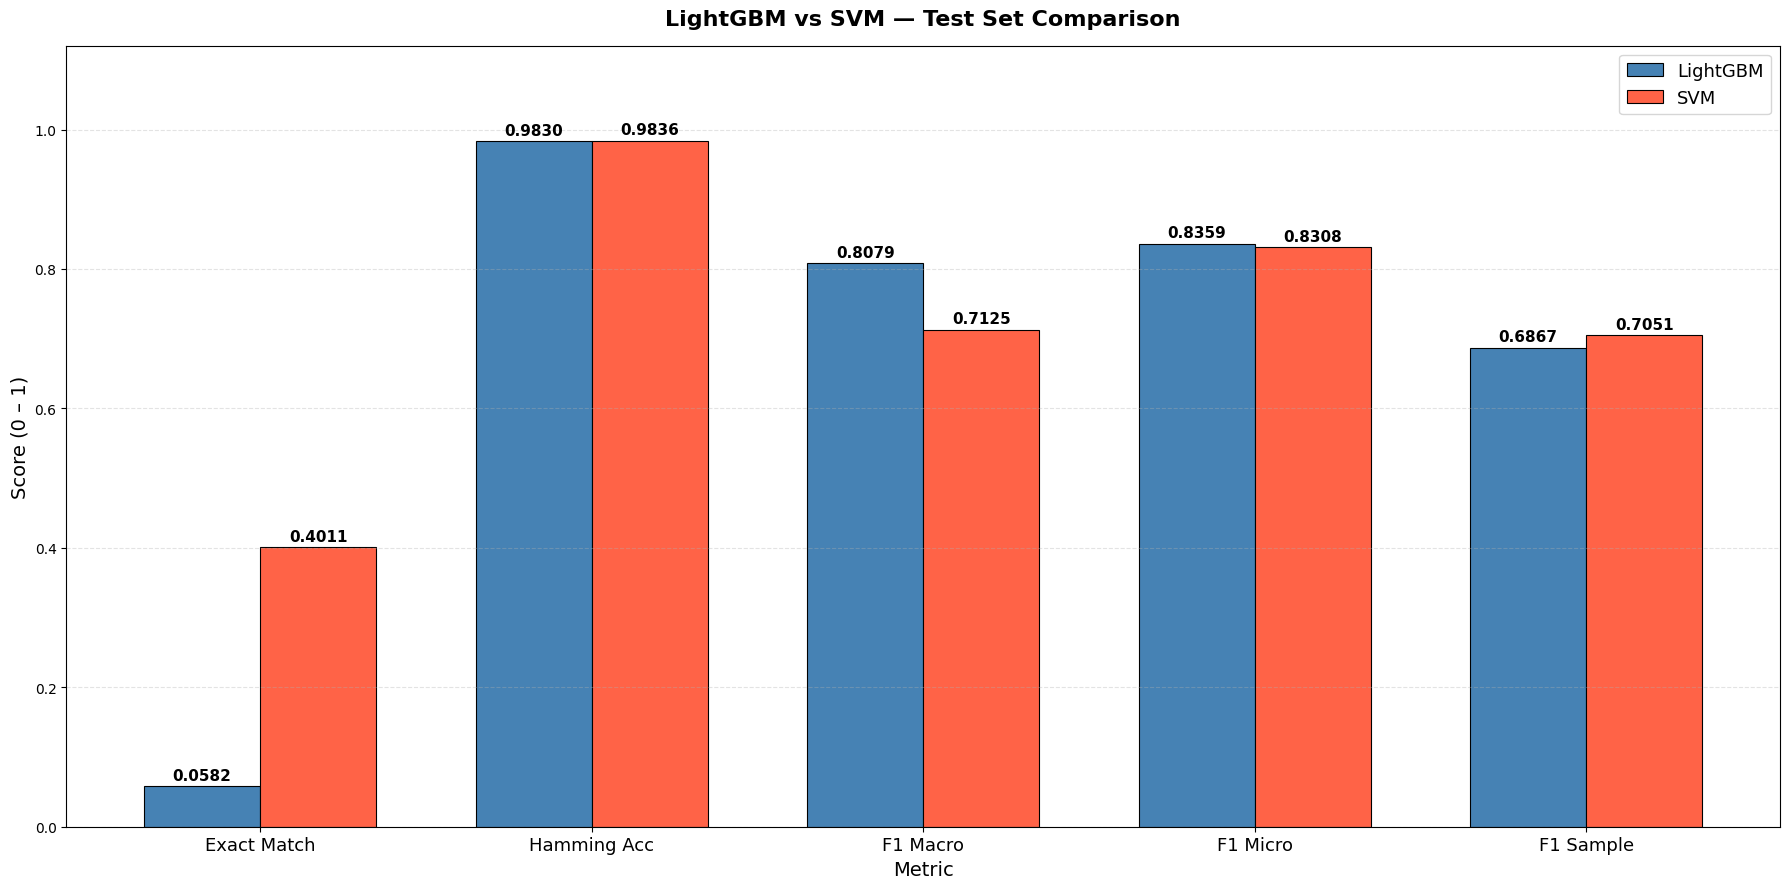

Chart saved.


In [ ]:
metrics     = ['Exact Match', 'Hamming Acc', 'F1 Macro', 'F1 Micro', 'F1 Sample']
metric_keys = ['exact_match', 'hamming_acc', 'f1_macro', 'f1_micro', 'f1_sample']

lgb_vals = [lgb_test_res[k] for k in metric_keys]
svm_vals = [svm_test_res[k] for k in metric_keys]

x     = np.arange(len(metrics))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(18, 9))

bars_lgb = ax.bar(x - bar_w/2, lgb_vals, bar_w, label='LightGBM', color='steelblue', edgecolor='black', linewidth=0.8)
bars_svm = ax.bar(x + bar_w/2, svm_vals, bar_w, label='SVM',       color='tomato',    edgecolor='black', linewidth=0.8)

for bar in bars_lgb.patches + bars_svm.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
            f'{h:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Metric', fontsize=14)
ax.set_ylabel('Score (0 – 1)', fontsize=14)
ax.set_title('LightGBM vs SVM — Test Set Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=13)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=13, loc='upper right')
ax.grid(axis='y', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.savefig(str(CKPT_DIR / 'lgbm_vs_svm_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')
